In [1]:
import os
import gc
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

In [2]:
def load_and_aggregate_soil(soil_files, t2m_file):
    def preprocess(ds):
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        if 'expver' in ds.dims: ds = ds.mean(dim='expver')
        return ds.sortby('time')

    df_daily = pd.DataFrame()
    
    for i, file_name in enumerate(soil_files, 1):
        ds_soil = preprocess(xr.open_dataset(os.path.join(folder_path, file_name)))
        var_name = list(ds_soil.data_vars)[0]
        # Tính trung bình không gian và chuyển sang độ C
        soil_temp = (ds_soil[var_name] - 273.15).mean(dim=['latitude', 'longitude']).resample(time='1D').mean().compute()
        df_daily[f'soil_level_{i}'] = soil_temp.values
        ds_soil.close()
        gc.collect()

    ds_t2m = preprocess(xr.open_dataset(os.path.join(folder_path, t2m_file)))
    var_t2m = list(ds_t2m.data_vars)[0]
    t2m = (ds_t2m[var_t2m] - 273.15).mean(dim=['latitude', 'longitude']).resample(time='1D').mean().compute()
    df_daily['t2m'] = t2m.values
    df_daily.index = t2m.time.values
    ds_t2m.close()

    df_monthly = df_daily.resample('ME').mean()
    df_yearly = df_daily.resample('YS').mean()
    
    climatology = df_monthly.groupby(df_monthly.index.month).mean()
    
    df_monthly['month'] = df_monthly.index.month
    df_monthly['year'] = df_monthly.index.year
    
    df_anomaly = pd.DataFrame(index=df_monthly.index)
    df_anomaly['year'] = df_monthly['year']
    df_anomaly['month'] = df_monthly['month']
    
    soil_vars = ['soil_level_1', 'soil_level_2', 'soil_level_3', 'soil_level_4']
    for var in soil_vars:
        df_anomaly[var] = df_monthly[var] - df_monthly['month'].map(climatology[var])

    gc.collect()
    return df_daily, df_monthly, df_yearly, df_anomaly, climatology

In [3]:
soil_files = [
    'soil_temperature_level_1_merged.nc',
    'soil_temperature_level_2_merged.nc',
    'soil_temperature_level_3_merged.nc',
    'soil_temperature_level_4_merged.nc'
]
t2m_file = '2m_temperature_merged.nc'

df_daily, df_monthly, df_yearly, df_anomaly, climatology = load_and_aggregate_soil(soil_files, t2m_file)
soil_vars = ['soil_level_1', 'soil_level_2', 'soil_level_3', 'soil_level_4']
layer_names = ["7cm", "28cm", "100cm", "289cm"]
depths = [0.035, 0.175, 0.640, 1.945]
colors = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4']

df_daily.head()

,soil_level_1,soil_level_2,soil_level_3,soil_level_4,t2m
1980-01-01,23.697496,23.365433,23.078300,23.876762,23.688828
1980-01-02,23.644108,23.420876,23.136520,23.841618,23.533554
1980-01-03,23.837681,23.456753,23.225826,23.846254,23.554111
1980-01-04,23.823811,23.462595,23.340425,23.892406,22.988262
1980-01-05,23.252453,23.251949,23.438145,23.950239,21.940742


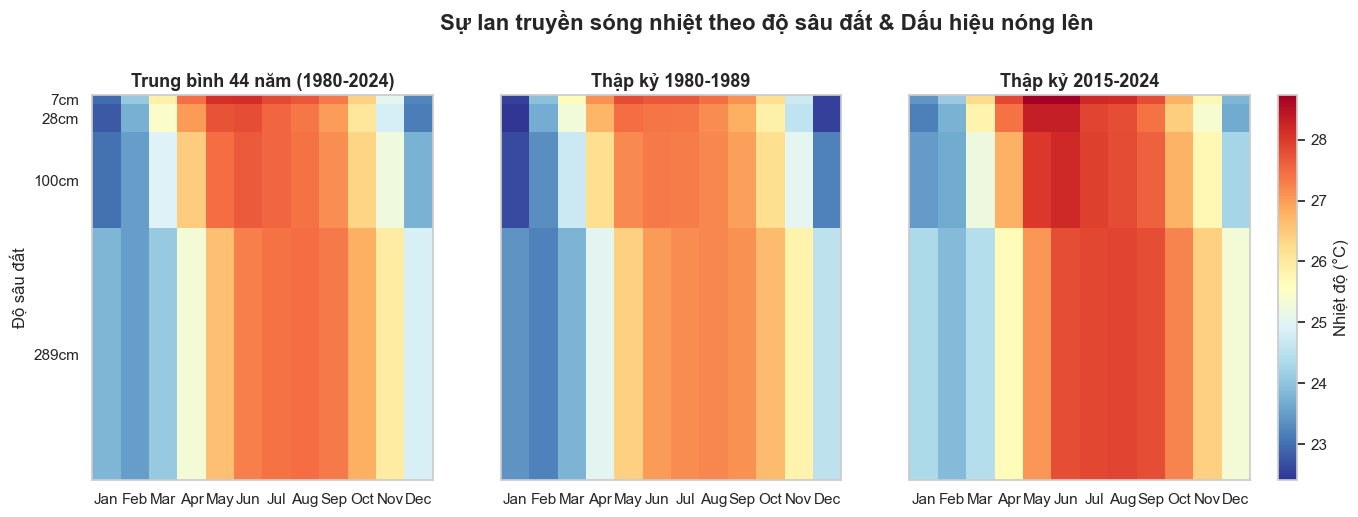

In [ ]:

clim_80s = df_monthly.loc['1980':'1989'].groupby(df_monthly.loc['1980':'1989'].index.month).mean()
clim_recent = df_monthly.loc['2015':'2024'].groupby(df_monthly.loc['2015':'2024'].index.month).mean()

clim_vals_all = climatology[soil_vars].values.T
clim_vals_80s = clim_80s[soil_vars].values.T
clim_vals_recent = clim_recent[soil_vars].values.T

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={'width_ratios': [1, 1, 1]}, sharey=True)
vmin = np.min([clim_vals_80s, clim_vals_recent])
vmax = np.max([clim_vals_80s, clim_vals_recent])

titles = ['Trung bình 45 năm (1980-2024)', 'Thập kỷ 1980-1989', 'Thập kỷ 2015-2024']
data_list = [clim_vals_all, clim_vals_80s, clim_vals_recent]

plot_depths = [0, 0.07, 0.28, 1.00, 2.89]

for i, ax in enumerate(axes):
    c = ax.pcolormesh(range(1, 14), plot_depths, data_list[i], cmap="RdYlBu_r", shading="flat", vmin=vmin, vmax=vmax)
    ax.set_yticks(depths)
    ax.set_yticklabels(layer_names)
    ax.set_xticks(np.arange(1.5, 13.5))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    ax.set_title(titles[i], fontsize=13, fontweight='bold')
    if i == 0: ax.set_ylabel("Độ sâu đất")

axes[0].invert_yaxis()
cbar = fig.colorbar(c, ax=axes.ravel().tolist(), label="Nhiệt độ (°C)", pad=0.02)
plt.suptitle("Sự lan truyền sóng nhiệt theo độ sâu đất & Dấu hiệu nóng lên", y=1.05, fontsize=16, fontweight='bold')
plt.show()

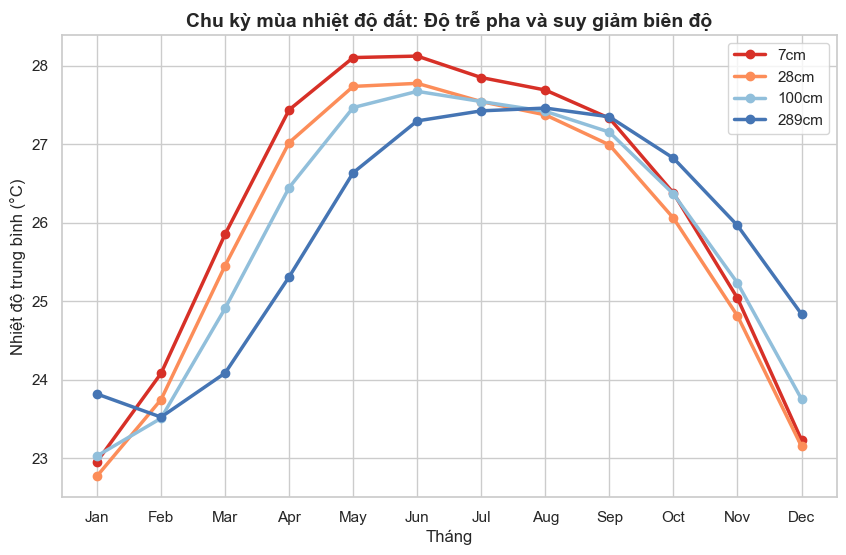

In [ ]:
plt.figure(figsize=(10, 6))

for var, color, name in zip(soil_vars, colors, layer_names):
    plt.plot(climatology.index, climatology[var], marker='o', linewidth=2.5, color=color, label=name)

plt.title("Chu kỳ mùa nhiệt độ đất: Độ trễ pha và suy giảm biên độ", fontsize=14, fontweight='bold')
plt.xlabel("Tháng")
plt.ylabel("Nhiệt độ trung bình (°C)")
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.show()

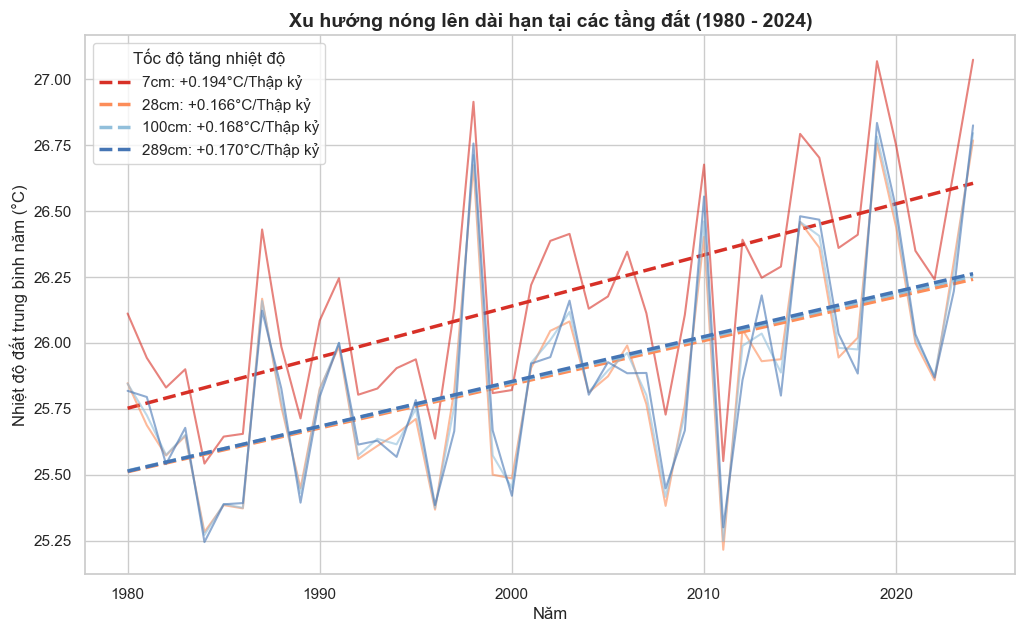

In [ ]:
plt.figure(figsize=(12, 7))

for var, color, name in zip(soil_vars, colors, layer_names):
    y_vals = df_yearly[var].values
    x_vals = df_yearly.index.year.values
    
    # Hồi quy tuyến tính để tính trend
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)
    trend_line = intercept + slope * x_vals
    
    plt.plot(x_vals, y_vals, color=color, alpha=0.6, linewidth=1.5)
    plt.plot(x_vals, trend_line, color=color, linestyle='--', linewidth=2.5, 
             label=f"{name}: +{slope*10:0.3f}°C/Thập kỷ")

plt.title("Xu hướng nóng lên dài hạn tại các tầng đất (1980 - 2024)", fontsize=14, fontweight='bold')
plt.xlabel("Năm")
plt.ylabel("Nhiệt độ đất trung bình năm (°C)")
plt.legend(title="Tốc độ tăng nhiệt độ")
plt.show()

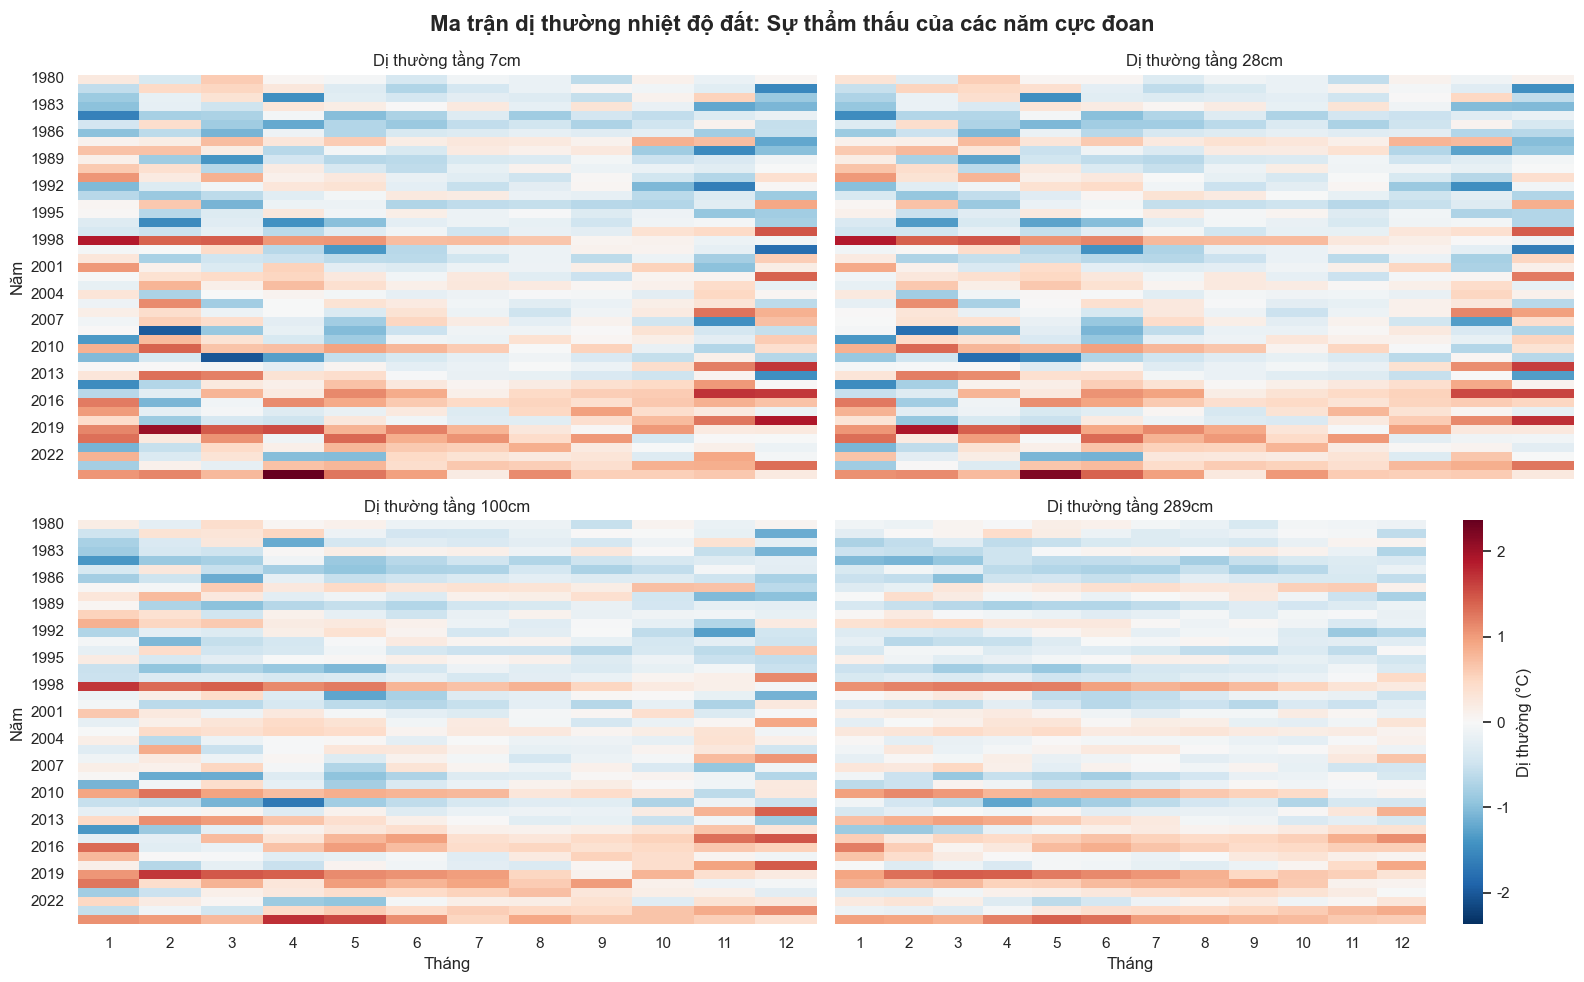

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

vmax_anom = np.abs(df_anomaly[soil_vars]).max().max()

for i, var in enumerate(soil_vars):
    pivot_table = df_anomaly.pivot(index='year', columns='month', values=var)
    sns.heatmap(pivot_table, ax=axes[i], cmap="RdBu_r", center=0, 
                vmin=-vmax_anom, vmax=vmax_anom, cbar=(i==3), 
                cbar_kws={'label': 'Dị thường (°C)'} if i==3 else None)
    
    axes[i].set_title(f"Dị thường tầng {layer_names[i]}")
    axes[i].set_ylabel("Năm" if i in [0, 2] else "")
    axes[i].set_xlabel("Tháng" if i in [2, 3] else "")

plt.suptitle("Ma trận dị thường nhiệt độ đất: Sự thẩm thấu của các năm cực đoan", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

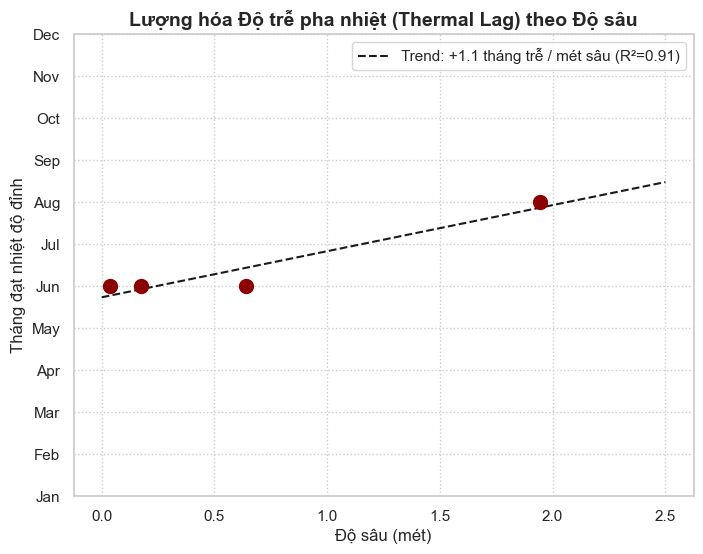

In [ ]:
peak_months = climatology[soil_vars].idxmax().values

plt.figure(figsize=(8, 6))
plt.scatter(depths, peak_months, color='darkred', s=100, zorder=5)

slope_lag, int_lag, r_lag, _, _ = stats.linregress(depths, peak_months)
x_plot = np.linspace(0, 2.5, 100)
plt.plot(x_plot, int_lag + slope_lag * x_plot, 'k--', 
         label=f"Trend: +{slope_lag:.1f} tháng trễ / mét sâu (R²={r_lag**2:.2f})")

plt.title("Lượng hóa Độ trễ pha nhiệt (Thermal Lag) theo Độ sâu", fontsize=14, fontweight='bold')
plt.xlabel("Độ sâu (mét)")
plt.ylabel("Tháng đạt nhiệt độ đỉnh")
plt.yticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

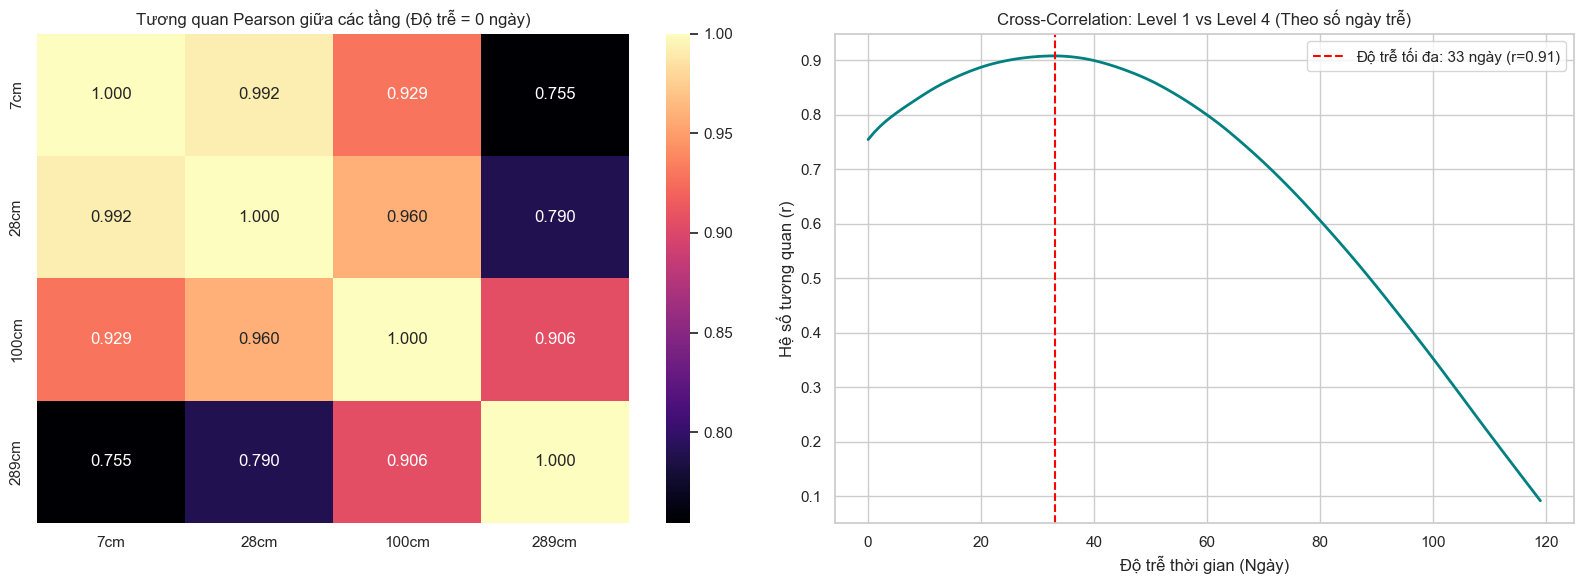

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = df_daily[soil_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="magma", ax=ax1, 
            xticklabels=layer_names, yticklabels=layer_names)
ax1.set_title("Tương quan Pearson giữa các tầng (Độ trễ = 0 ngày)")

lags = np.arange(0, 120, 1)
corrs = [df_daily['soil_level_1'].corr(df_daily['soil_level_4'].shift(-lag)) for lag in lags]

max_lag = lags[np.argmax(corrs)]
max_corr = np.max(corrs)

ax2.plot(lags, corrs, color='teal', linewidth=2)
ax2.axvline(max_lag, color='red', linestyle='--', label=f'Độ trễ tối đa: {max_lag} ngày (r={max_corr:.2f})')
ax2.set_title("Cross-Correlation: Level 1 vs Level 4 (Theo số ngày trễ)")
ax2.set_xlabel("Độ trễ thời gian (Ngày)")
ax2.set_ylabel("Hệ số tương quan (r)")
ax2.legend()

plt.tight_layout()
plt.show()

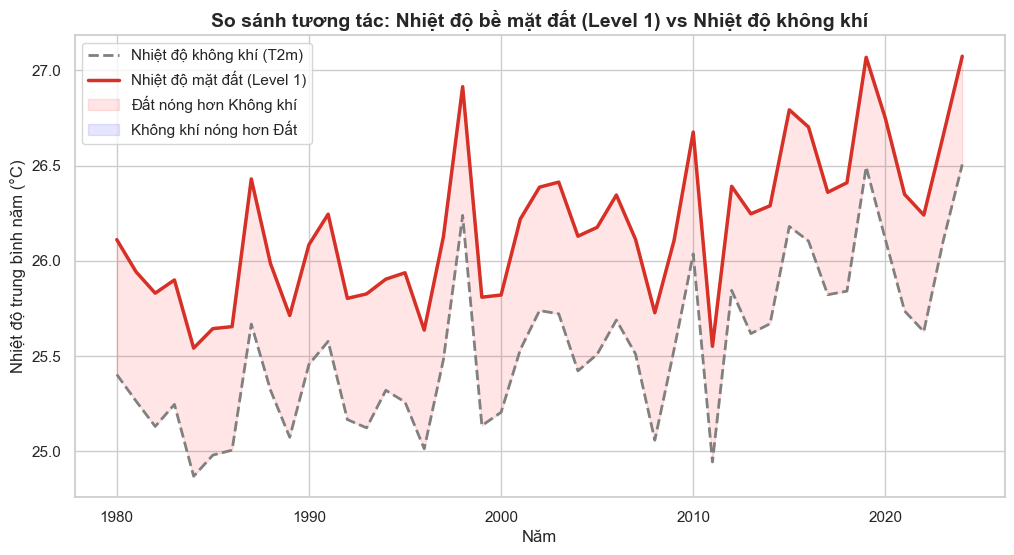

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df_yearly.index.year, df_yearly['t2m'], label='Nhiệt độ không khí (T2m)', color='gray', linewidth=2, linestyle='--')
plt.plot(df_yearly.index.year, df_yearly['soil_level_1'], label='Nhiệt độ mặt đất (Level 1)', color='#d73027', linewidth=2.5)

plt.fill_between(df_yearly.index.year, df_yearly['t2m'], df_yearly['soil_level_1'], 
                 where=(df_yearly['soil_level_1'] > df_yearly['t2m']), 
                 interpolate=True, color='red', alpha=0.1, label='Đất nóng hơn Không khí')
plt.fill_between(df_yearly.index.year, df_yearly['t2m'], df_yearly['soil_level_1'], 
                 where=(df_yearly['soil_level_1'] <= df_yearly['t2m']), 
                 interpolate=True, color='blue', alpha=0.1, label='Không khí nóng hơn Đất')

plt.title("So sánh tương tác: Nhiệt độ bề mặt đất (Level 1) vs Nhiệt độ không khí", fontsize=14, fontweight='bold')
plt.xlabel("Năm")
plt.ylabel("Nhiệt độ trung bình năm (°C)")
plt.legend()
plt.show()